# Fase 4a — Modelado: Línea base + ML tradicional

Baseline (clase mayoritaria) + **Random Forest** y **SVM (RBF)** sobre features color HSV + HOG, con `GridSearchCV` (CV=3, scoring=f1_macro) y class_weight.

> Conclusiones en `reports/04_modelado.md`. Aquí solo código y figuras. Los modelos y features se cachean en `artifacts/` para la Fase 5.

## 0. Configuración

In [1]:
import sys, time
from pathlib import Path
root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from sklearn.model_selection import GridSearchCV

from src.data.dataset import build_index, QUALITY_ORDER
from src.data import preprocess as pp
from src.models import ml_models as mlm
from src.evaluation.metrics import evaluate, plot_confusion, summary_row

sns.set_theme(style='whitegrid')
ART = root / 'artifacts'; ART.mkdir(exist_ok=True)
print('artifacts:', ART)

artifacts: /home/heiner/Documentos/apo_III/proyecto_final/ETLInfrati/artifacts


## 1. Datos: índice limpio + splits

In [2]:
df = pp.make_splits(pp.clean_index(build_index()))
print(df['split'].value_counts().to_dict())

{'train': 5461, 'test': 1171, 'val': 1171}


## 2. Extracción de características (color HSV + HOG)

Se extraen para train/val/test y se cachean en `artifacts/features.npz` (regenerable; acelera la Fase 5).

In [3]:
feat_path = ART / 'features.npz'
if feat_path.exists():
    d = np.load(feat_path, allow_pickle=True)
    Xtr, ytr, Xva, yva, Xte, yte = d['Xtr'], d['ytr'], d['Xva'], d['yva'], d['Xte'], d['yte']
    print('Features cargadas de cache:', feat_path.name)
else:
    t0 = time.time()
    Xtr, ytr = pp.extract_features(df[df.split=='train'])
    Xva, yva = pp.extract_features(df[df.split=='val'])
    Xte, yte = pp.extract_features(df[df.split=='test'])
    np.savez_compressed(feat_path, Xtr=Xtr, ytr=ytr, Xva=Xva, yva=yva, Xte=Xte, yte=yte)
    print(f'Extracción completa en {time.time()-t0:.0f}s -> {feat_path.name}')
print('X_train:', Xtr.shape, '| X_val:', Xva.shape, '| X_test:', Xte.shape)

  procesadas 1000/5461 imágenes...


  procesadas 2000/5461 imágenes...


  procesadas 3000/5461 imágenes...


  procesadas 4000/5461 imágenes...


  procesadas 5000/5461 imágenes...


  procesadas 1000/1171 imágenes...


  procesadas 1000/1171 imágenes...


Extracción completa en 485s -> features.npz
X_train: (5461, 1860) | X_val: (1171, 1860) | X_test: (1171, 1860)


## 3. Línea base (clase mayoritaria)

In [4]:
base = mlm.build_baseline().fit(Xtr, ytr)
base_pred = base.predict(Xva)
print('Baseline en validación:')
print(summary_row('Baseline (mayoría)', yva, base_pred))

Baseline en validación:
{'modelo': 'Baseline (mayoría)', 'macro_f1': np.float64(0.2012), 'balanced_acc': np.float64(0.3333), 'recall_Bad': np.float64(0.0)}


## 4. Random Forest (GridSearchCV)

In [5]:
rf, rf_params = mlm.rf_grid()
t0 = time.time()
rf_gs = GridSearchCV(rf, rf_params, scoring='f1_macro', cv=3, n_jobs=-1, verbose=0)
rf_gs.fit(Xtr, ytr)
print(f'RF entrenado en {time.time()-t0:.0f}s')
print('Mejores hiperparámetros:', rf_gs.best_params_)
print(f'Mejor Macro-F1 (CV): {rf_gs.best_score_:.4f}')
rf_pred = rf_gs.predict(Xva)
print(summary_row('Random Forest', yva, rf_pred))
joblib.dump(rf_gs.best_estimator_, ART / 'rf.pkl')

RF entrenado en 90s
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
Mejor Macro-F1 (CV): 0.7974
{'modelo': 'Random Forest', 'macro_f1': np.float64(0.9503), 'balanced_acc': np.float64(0.94), 'recall_Bad': np.float64(0.8421)}


['/home/heiner/Documentos/apo_III/proyecto_final/ETLInfrati/artifacts/rf.pkl']

## 5. SVM (RBF) con GridSearchCV

In [6]:
svm, svm_params = mlm.svm_grid()
t0 = time.time()
svm_gs = GridSearchCV(svm, svm_params, scoring='f1_macro', cv=3, n_jobs=-1, verbose=0)
svm_gs.fit(Xtr, ytr)
print(f'SVM entrenado en {time.time()-t0:.0f}s')
print('Mejores hiperparámetros:', svm_gs.best_params_)
print(f'Mejor Macro-F1 (CV): {svm_gs.best_score_:.4f}')
svm_pred = svm_gs.predict(Xva)
print(summary_row('SVM (RBF)', yva, svm_pred))
joblib.dump(svm_gs.best_estimator_, ART / 'svm.pkl')

SVM entrenado en 47s
Mejores hiperparámetros: {'svc__C': 10, 'svc__gamma': 'scale'}
Mejor Macro-F1 (CV): 0.8023


{'modelo': 'SVM (RBF)', 'macro_f1': np.float64(0.9551), 'balanced_acc': np.float64(0.9513), 'recall_Bad': np.float64(0.8947)}


['/home/heiner/Documentos/apo_III/proyecto_final/ETLInfrati/artifacts/svm.pkl']

## 6. Comparación en validación

,macro_f1,balanced_acc,recall_Bad
modelo,,,
Baseline (mayoría),0.2012,0.3333,0.0000
Random Forest,0.9503,0.9400,0.8421
SVM (RBF),0.9551,0.9513,0.8947


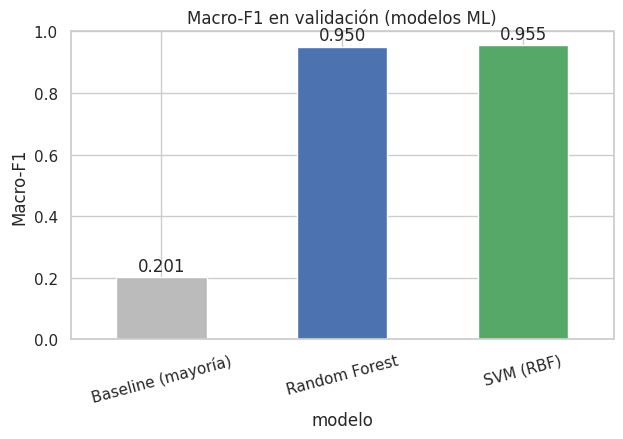

In [7]:
rows = [summary_row('Baseline (mayoría)', yva, base_pred),
        summary_row('Random Forest', yva, rf_pred),
        summary_row('SVM (RBF)', yva, svm_pred)]
comp = pd.DataFrame(rows).set_index('modelo')
display(comp)

fig, ax = plt.subplots(figsize=(7, 4))
comp['macro_f1'].plot(kind='bar', ax=ax, color=['#bbbbbb', '#4c72b0', '#55a868'])
ax.set_title('Macro-F1 en validación (modelos ML)'); ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1); plt.xticks(rotation=15)
for i, v in enumerate(comp['macro_f1']): ax.text(i, v+0.02, f'{v:.3f}', ha='center')
plt.show()

## 7. Matrices de confusión en validación (RF y SVM)

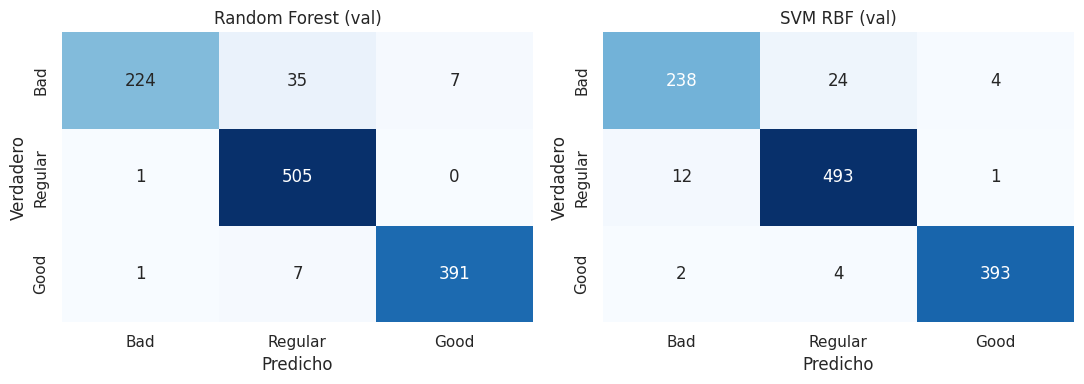

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_confusion(yva, rf_pred, axes[0], 'Random Forest (val)')
plot_confusion(yva, svm_pred, axes[1], 'SVM RBF (val)')
plt.tight_layout(); plt.show()

## 8. Reporte por clase del mejor modelo ML (validación)

In [9]:
best_name = comp['macro_f1'].idxmax()
best_pred = {'Random Forest': rf_pred, 'SVM (RBF)': svm_pred}.get(best_name, rf_pred)
print('Mejor modelo ML en validación:', best_name)
from sklearn.metrics import classification_report
print(classification_report(yva, best_pred, labels=QUALITY_ORDER, zero_division=0))

Mejor modelo ML en validación: SVM (RBF)
              precision    recall  f1-score   support

         Bad       0.94      0.89      0.92       266
     Regular       0.95      0.97      0.96       506
        Good       0.99      0.98      0.99       399

    accuracy                           0.96      1171
   macro avg       0.96      0.95      0.96      1171
weighted avg       0.96      0.96      0.96      1171

